In [27]:
import pandas as pd
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.utils import resample
import dill as pickle


In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\omar abo
[nltk_data]     elmaaty\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\omar abo
[nltk_data]     elmaaty\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("spam_ham_dataset.csv/spam_ham_dataset.csv")
df = df[["text", "label"]]
df.head()

,text,label
0,Subject: enron methanol ; meter # : 988291\r\n...,ham
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",ham
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",ham
3,"Subject: photoshop , windows , office . cheap ...",spam
4,Subject: re : indian springs\r\nthis deal is t...,ham


In [4]:
df.dropna(subset=["text"], inplace=True)
df.drop_duplicates(subset=["text"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4993 entries, 0 to 5170
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    4993 non-null   object
 1   label   4993 non-null   object
dtypes: object(2)
memory usage: 117.0+ KB


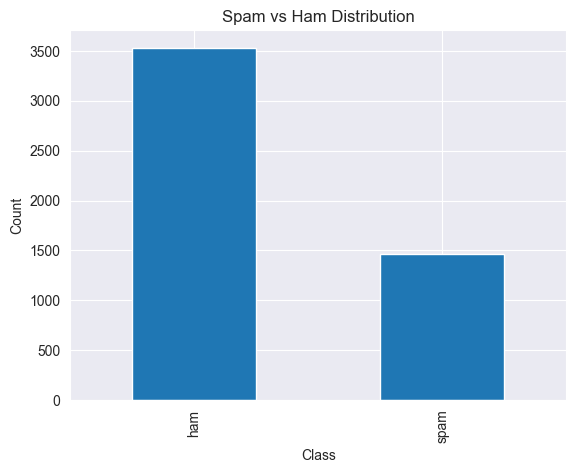

In [5]:
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [6]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()                       # lowercase
    text = re.sub(r"http\S+|www\S+", "", text) # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)    # remove numbers and punctuation
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)


In [7]:
df["clean_text"] = df["text"].apply(preprocess)
df.head()

,text,label,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,ham,subject enron methanol meter follow note gave ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",ham,subject hpl nom januari see attach file hplnol...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",ham,subject neon retreat ho ho ho around wonder ti...
3,"Subject: photoshop , windows , office . cheap ...",spam,subject photoshop window offic cheap main tren...
4,Subject: re : indian springs\r\nthis deal is t...,ham,subject indian spring deal book teco pvr reven...


In [28]:
ham = df[df['label'] == 'ham']
spam = df[df['label'] == 'spam']

spam_upsampled = resample(
    spam,
    replace=True,
    n_samples=len(ham),
    random_state=42
)

df = pd.concat([ham, spam_upsampled])
df = df.sample(frac=1, random_state=42)

print(df['label'].value_counts())


label
spam    3531
ham     3531
Name: count, dtype: int64


In [8]:
def build_ngram(tokens_list, n):
    counts = Counter()
    for tokens in tokens_list:
        counts.update(ngrams(tokens, n))
    return counts

unigrams = build_ngram(df["clean_text"].apply(lambda x: x.split()), 1)
bigrams  = build_ngram(df["clean_text"].apply(lambda x: x.split()), 2)

print("Top 10 Unigrams:", unigrams.most_common(10))
print("Top 10 Bigrams:", bigrams.most_common(10))

Top 10 Unigrams: [(('ect',), 13701), (('subject',), 7832), (('hou',), 7182), (('enron',), 6442), (('com',), 3702), (('deal',), 3587), (('pleas',), 3178), (('ga',), 2961), (('meter',), 2712), (('cc',), 2336)]
Top 10 Bigrams: [(('hou', 'ect'), 7119), (('ect', 'ect'), 6246), (('enron', 'enron'), 1404), (('ect', 'cc'), 1356), (('corp', 'enron'), 1171), (('cc', 'subject'), 1065), (('let', 'know'), 929), (('daren', 'j'), 926), (('enron', 'com'), 830), (('j', 'farmer'), 783)]


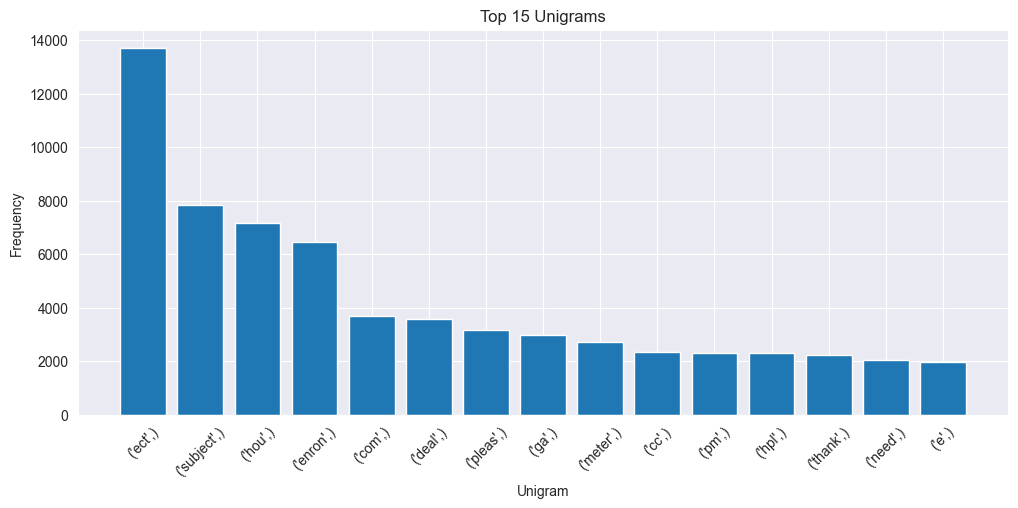

In [9]:
top_uni = unigrams.most_common(15)
labels_uni, values_uni = zip(*top_uni)

x = np.arange(len(labels_uni))  # numeric x positions

plt.figure(figsize=(12,5))
plt.bar(x, values_uni)
plt.xticks(x, labels_uni, rotation=45)
plt.title("Top 15 Unigrams")
plt.xlabel("Unigram")
plt.ylabel("Frequency")
plt.show()

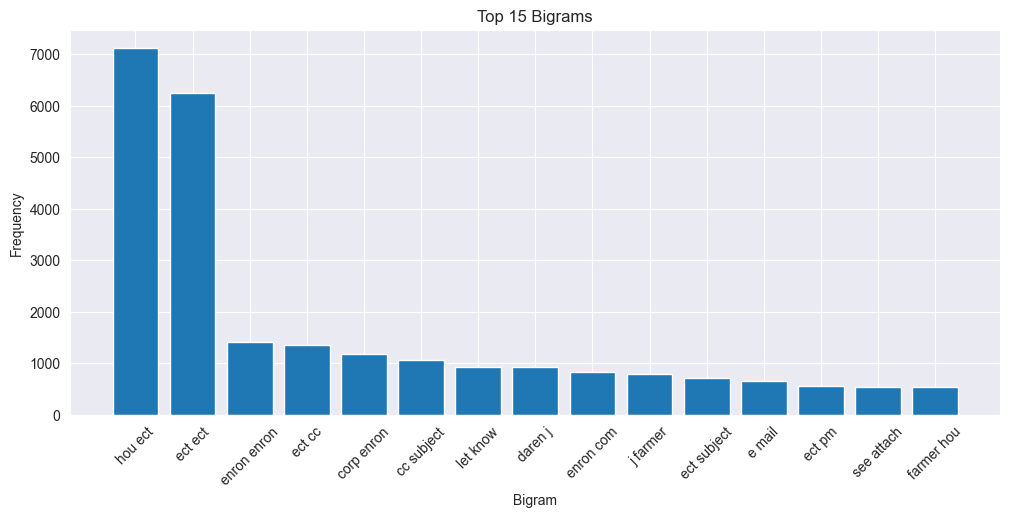

In [10]:
top_bi = bigrams.most_common(15)
labels_bi = [' '.join(b) for b, _ in top_bi]
values_bi = [v for _, v in top_bi]

x = np.arange(len(labels_bi))

plt.figure(figsize=(12,5))
plt.bar(x, values_bi)
plt.xticks(x, labels_bi, rotation=45)
plt.title("Top 15 Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.show()

In [11]:
V = len(unigrams)  # vocabulary size

def bigram_probability(w1, w2):
    bigram_count = bigrams[(w1, w2)]
    unigram_count = unigrams[(w1,)]
    return (bigram_count + 1) / (unigram_count + V)

In [12]:
def recommend_next_word(current_word, top_k=5):
    candidates = []
    for (w1, w2), count in bigrams.items():
        if w1 == current_word:
            prob = bigram_probability(w1, w2)
            candidates.append((w2, prob))

    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
    return candidates[:top_k]

In [13]:
word = "free"
print(f"Next word recommendations for '{word}':\n")
for w, p in recommend_next_word(word):
    print(f"- {w}  (prob={p:.6f})")

Next word recommendations for 'free':

- zone  (prob=0.001093)
- zonedubai  (prob=0.000989)
- call  (prob=0.000729)
- email  (prob=0.000573)
- ship  (prob=0.000547)


In [14]:
def complete_sentence(sentence, top_k=5):
    sentence = preprocess(sentence)
    words = sentence.split()
    if not words:
        return []

    last_word = words[-1]
    return recommend_next_word(last_word, top_k)

In [15]:
print(complete_sentence("please confirm your"))

[('volum', 0.0008615063307662185), ('march', 0.0002610625244746117), ('account', 0.0002610625244746117), ('actual', 0.0002349562720271505), ('thank', 0.0002349562720271505)]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=42
)

In [17]:
binary_vectorizer = CountVectorizer(binary=True)
X_train_bin = binary_vectorizer.fit_transform(X_train)
X_test_bin  = binary_vectorizer.transform(X_test)

In [18]:
model_bin = LogisticRegression(max_iter=200)
model_bin.fit(X_train_bin, y_train)

pred_bin = model_bin.predict(X_test_bin)

# Added
train_pred_bin = model_bin.predict(X_train_bin)
print("Binary Train Accuracy:", accuracy_score(y_train, train_pred_bin))
print("Binary Test Accuracy:", accuracy_score(y_test, pred_bin))

print(classification_report(y_test, pred_bin))

Binary Train Accuracy: 0.99949924887331
Binary Test Accuracy: 0.972972972972973
              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       732
        spam       0.94      0.96      0.95       267

    accuracy                           0.97       999
   macro avg       0.96      0.97      0.97       999
weighted avg       0.97      0.97      0.97       999



In [19]:
count_vectorizer = CountVectorizer()
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count  = count_vectorizer.transform(X_test)

In [20]:
model_count = LogisticRegression(max_iter=200)
model_count.fit(X_train_count, y_train)

pred_count = model_count.predict(X_test_count)

# Added
train_pred_count = model_count.predict(X_train_count)
print("Count Train Accuracy:", accuracy_score(y_train, train_pred_count))
print("Count Test Accuracy:", accuracy_score(y_test, pred_count))

print(classification_report(y_test, pred_count))

Count Train Accuracy: 0.99949924887331
Count Test Accuracy: 0.970970970970971
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       732
        spam       0.93      0.97      0.95       267

    accuracy                           0.97       999
   macro avg       0.96      0.97      0.96       999
weighted avg       0.97      0.97      0.97       999



In [21]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

In [22]:
model_tfidf = LogisticRegression(max_iter=200)
model_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = model_tfidf.predict(X_test_tfidf)

# Added
train_pred_tfidf = model_tfidf.predict(X_train_tfidf)
print("TF-IDF Train Accuracy:", accuracy_score(y_train, train_pred_tfidf))
print("TF-IDF Test Accuracy:", accuracy_score(y_test, pred_tfidf))

print(classification_report(y_test, pred_tfidf))

TF-IDF Train Accuracy: 0.9967451176765147
TF-IDF Test Accuracy: 0.978978978978979
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       732
        spam       0.94      0.98      0.96       267

    accuracy                           0.98       999
   macro avg       0.97      0.98      0.97       999
weighted avg       0.98      0.98      0.98       999



In [23]:
print("Binary Accuracy:", accuracy_score(y_test, pred_bin))
print("Count Accuracy:", accuracy_score(y_test, pred_count))
print("TF-IDF Accuracy:", accuracy_score(y_test, pred_tfidf))

Binary Accuracy: 0.972972972972973
Count Accuracy: 0.970970970970971
TF-IDF Accuracy: 0.978978978978979


In [24]:
# Store model accuracies
accuracies = {
    "Binary": accuracy_score(y_test, pred_bin),
    "Count": accuracy_score(y_test, pred_count),
    "TF-IDF": accuracy_score(y_test, pred_tfidf)
}

# Select best model
best_model_name = max(accuracies, key=accuracies.get)
print(f"\nBest Model: {best_model_name} with accuracy = {accuracies[best_model_name]:.4f}")

# Map names to model + vectorizer
model_map = {
    "Binary":  (model_bin, binary_vectorizer),
    "Count":   (model_count, count_vectorizer),
    "TF-IDF":  (model_tfidf, tfidf_vectorizer)
}

best_model, best_vectorizer = model_map[best_model_name]

# Save model
with open("best_spam_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save vectorizer
with open("best_vectorizer.pkl", "wb") as f:
    pickle.dump(best_vectorizer, f)

print("Model and vectorizer saved successfully!")



Best Model: TF-IDF with accuracy = 0.9790
Model and vectorizer saved successfully!


In [25]:
class SpamModelWithRecommendation:
    def __init__(self, model, vectorizer, unigrams, bigrams):
        import re
        import nltk
        from nltk.corpus import stopwords
        from nltk.stem import PorterStemmer

        # Save modules inside the class (IMPORTANT)
        self.re = re
        self.word_tokenize = nltk.word_tokenize

        self.model = model
        self.vectorizer = vectorizer
        self.unigrams = unigrams
        self.bigrams = bigrams
        self.V = len(unigrams)

        # NLP tools
        self.stop_words = set(stopwords.words("english"))
        self.stemmer = PorterStemmer()

    def preprocess(self, text):
        text = text.lower()
        text = self.re.sub(r"http\S+|www\S+", "", text)
        text = self.re.sub(r"[^a-z\s]", " ", text)
        tokens = self.word_tokenize(text)
        tokens = [t for t in tokens if t not in self.stop_words]
        tokens = [self.stemmer.stem(t) for t in tokens]
        return " ".join(tokens)

    # Spam/Ham Prediction
    def predict(self, texts):
        X_vec = self.vectorizer.transform(texts)
        return self.model.predict(X_vec)

    def predict_proba(self, texts):
        X_vec = self.vectorizer.transform(texts)
        return self.model.predict_proba(X_vec)

    # Recommendation System
    def bigram_probability(self, w1, w2):
        bigram_count = self.bigrams.get((w1, w2), 0)
        unigram_count = self.unigrams.get((w1,), 0)
        return (bigram_count + 1) / (unigram_count + self.V)

    def recommend_next_word(self, current_word, top_k=5):
        candidates = []
        for (w1, w2), count in self.bigrams.items():
            if w1 == current_word:
                prob = self.bigram_probability(w1, w2)
                candidates.append((w2, prob))
        candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
        return candidates[:top_k]

    def complete_sentence(self, sentence, top_k=5):
        sentence = self.preprocess(sentence)
        words = sentence.split()
        if not words:
            return []
        last_word = words[-1]
        return [w for w, _ in self.recommend_next_word(last_word, top_k)]


In [26]:
combined_model = SpamModelWithRecommendation(
    model=best_model,
    vectorizer=best_vectorizer,
    unigrams=unigrams,
    bigrams=bigrams
)

with open("combined_spam_recommendation_model.pkl", "wb") as f:
    pickle.dump(combined_model, f)

print("Combined model saved successfully!")


Combined model saved successfully!
